# My details :
*   Name : Tushar Kaldate
*   Roll : 47
*   Batch : A2
* PRN : 202401040191

#GitHub Repo : [Tushar's GitHub](https://github.com/tusharkkp/AI-ML-Lab-Practicals/blob/main/Tushar_Kaldate_Vacuum_Cleaner_Reflex_Agent.ipynb)

# **AI-ML Lab Practical No. 1**


# 1. Title :

#Design and Implementation of a Simple Reflex Agent for an Autonomous Vacuum Cleaner Using Python
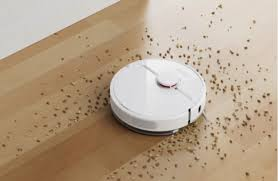
## Demonstrate PEAS Descriptors of Task Environment using Vacuum Cleaner Intelligent Agent Application

**Environment:** Computer Engineering Department, H-Wing, 3rd Floor  
**Blocks:** H-301 to H-310  
**Agent Architecture:** Simple Reflex Agent  
**Pathfinding:** Breadth-First Search (BFS)  
**Libraries:** Python Standard Library only


#2. Aim

To design and implement a **Simple Reflex Agent for an autonomous vacuum cleaner using Python** and demonstrate the **PEAS (Performance Measure, Environment, Actuators, Sensors)** description of an intelligent-agent task environment.

The vacuum cleaner operates on the **3rd Floor of the Computer Engineering Department's H-Wing**, consisting of 10 classroom blocks. The agent uses predefined condition-action rules for decision-making and BFS for shortest-path navigation between blocks and service stations.


# 3.  Objectives

1. Understand the concept of an intelligent agent and its environment.
2. Design a **Simple Reflex Agent** using condition-action rules.
3. Represent the H-Wing floor layout as a **graph**.
4. Use **BFS** to find the shortest path between locations.
5. Randomly initialize room conditions and agent resources.
6. Implement battery, water, and dust-bin threshold management.
7. Demonstrate automatic charging, water refilling, and dust-bin disposal.
8. Demonstrate the **PEAS descriptor** for the vacuum-cleaner task environment.
9. Analyze the behavior of the agent through simulation statistics.


# 4. Outcome

After completing this practical, the learner will be able to:

- Explain the architecture of a Simple Reflex Agent.
- Identify the PEAS components of an intelligent-agent application.
- Model an environment using a graph.
- Apply BFS for shortest-path navigation.
- Implement IF-THEN condition-action rules.
- Manage changing agent resources using thresholds.
- Analyze an autonomous agent's interaction with its environment.


# 5. Conceptual Details

### i. Intelligent Agent

An intelligent agent perceives its environment through sensors/percepts and performs actions using actuators. In this project, the vacuum cleaner observes its current location, room condition, battery, water level, and dust-bin level.

### ii. Simple Reflex Agent

A Simple Reflex Agent selects an action using the **current percept** and predefined condition-action rules.

Conceptually:

```text
CURRENT PERCEPT
      |
      v
Check Battery
      |
      v
Check Water
      |
      v
Check Dust-bin
      |
      v
Check Current Block
      |
      v
Select Action
```

The agent does not use machine learning, reinforcement learning, prediction, A*, Dijkstra, or complex planning.

### iii. PEAS Descriptor

| PEAS Component | Vacuum Cleaner Application |
|---|---|
| **Performance Measure** | Clean all blocks, minimize unnecessary movement, manage resources, complete cleaning successfully |
| **Environment** | H-Wing 3rd Floor, H-301 to H-310, charging station, water station, dust-bin station |
| **Actuators** | Move, clean, charge, refill water, empty dust-bin |
| **Sensors / Percepts** | Current location, room status, battery level, water level, dust-bin level |

### iv. BFS Navigation

The floor is represented as an **unweighted graph**:

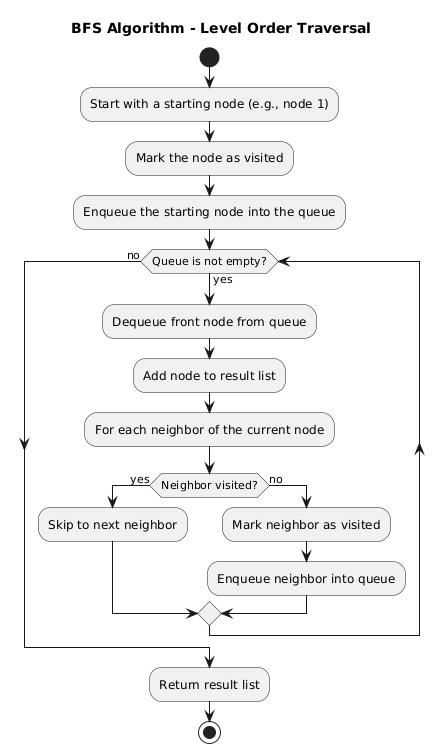

- Each block/station is a node.
- Each valid movement connection is an edge.
- BFS finds the shortest path between the current location and the selected destination.

The decision-making and navigation are deliberately separated.

### v. Resource Thresholds

- Battery threshold: **20%**
- Water threshold: **20%**
- Dust-bin threshold: **80% full**

Priority of reflex rules:

1. Battery ≤ 20% → Go to charging station.
2. Water ≤ 20% → Go to water-refilling station.
3. Dust-bin ≥ 80% → Go to disposal station.
4. Current block is dirty and resources are sufficient → Clean.
5. Dirty blocks remain → Navigate to the next dirty block.
6. No dirty blocks remain → Finish.

### vi. Resource Consumption

During the simulation:

- Movement decreases battery.
- Cleaning decreases battery.
- Cleaning decreases water.
- Cleaning increases dust-bin usage.
- Charging restores battery to 100%.
- Refilling restores water to 100%.
- Disposal empties the dust-bin to 0%.


# 6. Algorithm

1. Start the program.
2. Create the `Environment` object.
3. Create the 3rd-floor H-Wing graph.
4. Create 10 blocks: H-301 to H-310.
5. Randomly assign `Clean` or `Dirty` status to each block.
6. Create charging, water-refilling, and dust-bin stations.
7. Create the `Agent` object.
8. Randomly initialize battery, water, dust-bin level, and starting location.
9. Perceive the current environment state.
10. Apply the Simple Reflex condition-action rules.
11. If battery is at or below its threshold, navigate to the charging station using BFS.
12. If water is at or below its threshold, navigate to the water station using BFS.
13. If the dust-bin is at or above its threshold, navigate to the disposal station using BFS.
14. If the current block is dirty and resources are sufficient, clean it.
15. If another dirty block remains, select a destination and use BFS to navigate to it.
16. Decrease/increase resources according to movement, cleaning, and servicing.
17. Repeat until all 10 blocks are clean.
18. Display final simulation statistics.
19. Stop the program.
**Agent - Environment Flow**

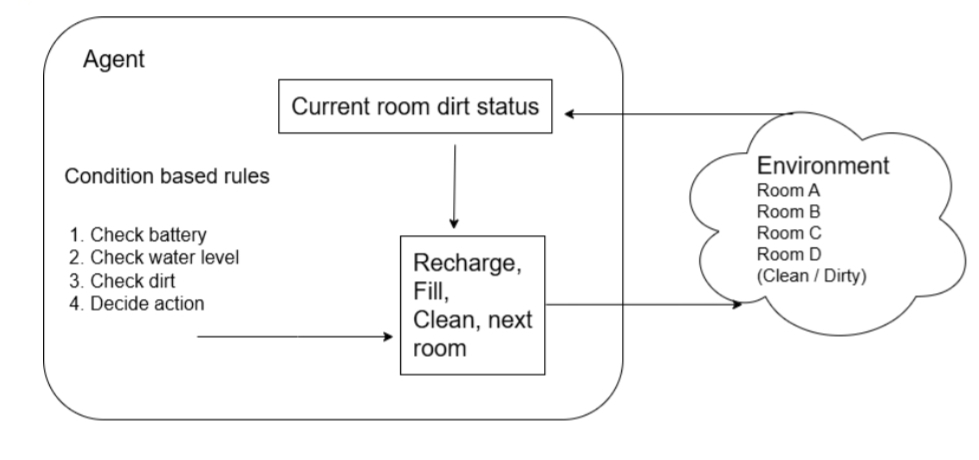

# 7. Flowchart

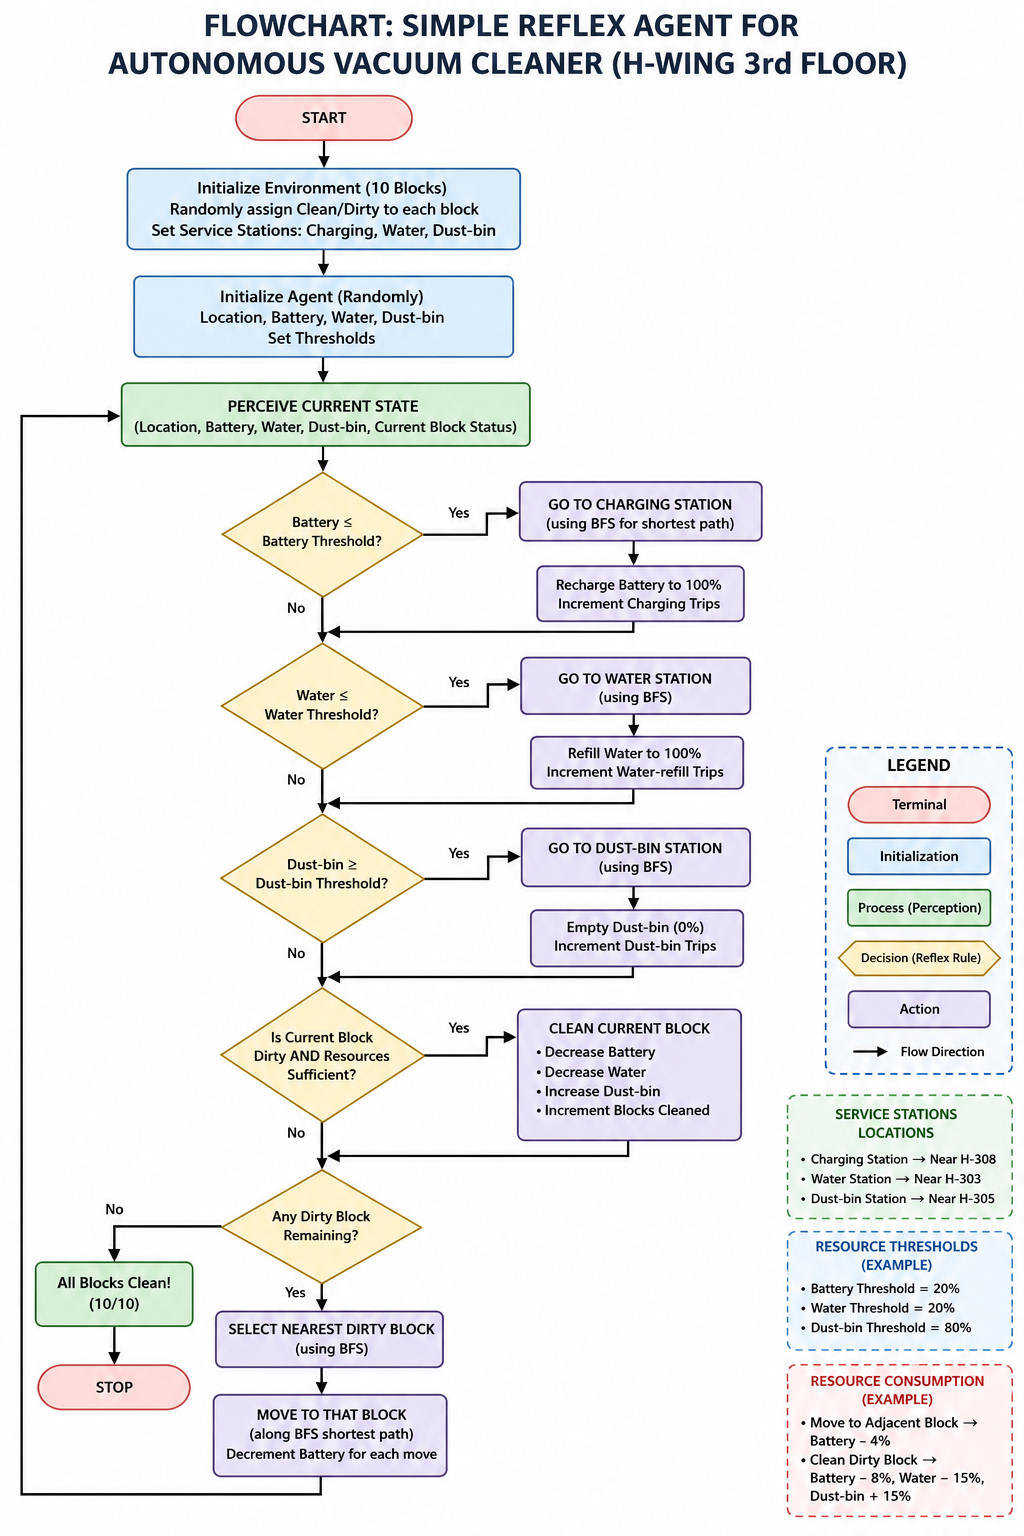

# 8. Code

In [3]:
import random
from collections import deque


class Environment:
    """
    Represents the Computer Engineering Department's H-Wing,
    3rd Floor.

    The floor contains 10 classrooms:
        H-301 to H-310

    The environment is represented as a graph.
    """

    def __init__(self):

        self.blocks = [
            "H-301", "H-302", "H-303", "H-304", "H-305",
            "H-306", "H-307", "H-308", "H-309", "H-310"
        ]

        # imp service locations
        self.charging_station = "CHARGING"
        self.water_station = "WATER"
        self.dustbin_station = "DUSTBIN"

        self.service_stations = [
            self.charging_station,
            self.water_station,
            self.dustbin_station
        ]

#ths is the graph of H wingg

        self.graph = {
            "H-301": ["H-302", "H-306"],
            "H-302": ["H-301", "H-303"],
            "H-303": ["H-302", "H-304", "WATER"],
            "H-304": ["H-303", "H-305"],
            "H-305": ["H-304", "H-306", "DUSTBIN"],
            "H-306": ["H-301", "H-305", "H-307"],
            "H-307": ["H-306", "H-308"],
            "H-308": ["H-307", "H-309", "CHARGING"],
            "H-309": ["H-308", "H-310"],
            "H-310": ["H-309"],

            # Service stations
            "CHARGING": ["H-308"],
            "WATER": ["H-303"],
            "DUSTBIN": ["H-305"]
        }


        # RANDMLYYYYYYYYYYYY
        self.room_status = {}

        for block in self.blocks:
            self.room_status[block] = random.choice(["Clean", "Dirty"])


        # Edge case : if random lib assigns all rooms are clean

        if all(status == "Clean" for status in self.room_status.values()):
            random_block = random.choice(self.blocks)
            self.room_status[random_block] = "Dirty"

    # BFS PATHFINDING

    def bfs(self, start, goal):
        """
        Breadth-First Search finds the shortest path from start
        location to goal location.

        BFS is responsible ONLY for navigation.
        It does not decide why the agent wants to go there.
        """

        queue = deque([[start]])
        visited = set()

        while queue:
            path = queue.popleft()
            current = path[-1]

            if current == goal:
                return path

            if current in visited:
                continue

            visited.add(current)

            for neighbour in self.graph[current]:
                if neighbour not in visited:
                    new_path = path + [neighbour]
                    queue.append(new_path)

        return []

    # ENVIRONMENT FUNCTIONS

    def is_dirty(self, block):
        return self.room_status[block] == "Dirty"

    def clean_block(self, block):
        self.room_status[block] = "Clean"

    def all_blocks_clean(self):
        return all(
            status == "Clean"
            for status in self.room_status.values()
        )

    def get_dirty_blocks(self):
        return [
            block
            for block in self.blocks
            if self.room_status[block] == "Dirty"
        ]

    def display_environment(self):
        print("\n========== H-WING 3RD FLOOR ==========")

        for block in self.blocks:
            print(
                f"{block}: {self.room_status[block]}"
            )

        print("=======================================")


class Agent:
    """
    Simple Reflex Agent representing the autonomous vacuum cleaner.

    The agent uses:
        - Current percept
        - Predefined IF-THEN rules
        - BFS for navigation
    """

    # RESOURCE PARAMETERS

    BATTERY_THRESHOLD = 20
    WATER_THRESHOLD = 20
    DUSTBIN_THRESHOLD = 80

    MAX_BATTERY = 100
    MAX_WATER = 100
    MAX_DUSTBIN = 100

    # Resource consumption
    MOVEMENT_COST = 4
    CLEANING_BATTERY_COST = 8
    CLEANING_WATER_COST = 15
    CLEANING_DUST_COST = 15

    def __init__(self, environment):
        self.environment = environment


        # Random initial resourcess

        self.battery = random.randint(30, 60)
        self.water = random.randint(30, 60)

        # Dust-bin represents percentage filled
        self.dustbin = random.randint(20, 60)

        # Random starting block
        self.current_location = random.choice(
            self.environment.blocks
        )

        # Agent statistics
        self.current_floor = "3rd Floor"
        self.cleaning_status = "Idle"

        self.blocks_cleaned = 0
        self.charging_trips = 0
        self.water_refilling_trips = 0
        self.dustbin_disposal_trips = 0

        self.total_moves = 0
        self.total_steps = 0

    # PERCEPTION

    def perceive(self):
        """
        The agent observes its CURRENT state.

        This is the perception stage of the Simple Reflex Agent.
        """

        current_block_status = None

        if self.current_location in self.environment.blocks:
            current_block_status = (
                self.environment.room_status[
                    self.current_location
                ]
            )

        percept = {
            "location": self.current_location,
            "battery": self.battery,
            "water": self.water,
            "dustbin": self.dustbin,
            "block_status": current_block_status
        }

        return percept

    # SIMPLE REFLEX DECISION MAKING

    def decide_action(self):
        """
        Simple Reflex Agent rules.

        Priority:

        1. Battery
        2. Water
        3. Dust-bin
        4. Clean current dirty block
        5. Move to next dirty block
        6. Finish

        This method decides WHAT the agent should do.

        It does NOT calculate paths.
        """

        percept = self.perceive()

        # RULE 1: Battery
        # IF battery <= threshold
        # THEN go to charging station
        if percept["battery"] <= self.BATTERY_THRESHOLD:
            return "CHARGE"

        # RULE 2: Water
        # IF water <= threshold
        # THEN go to water station
        if percept["water"] <= self.WATER_THRESHOLD:
            return "REFILL_WATER"

        # RULE 3: Dust-bin
        # IF dust-bin >= threshold
        # THEN go to disposal station
        if percept["dustbin"] >= self.DUSTBIN_THRESHOLD:
            return "EMPTY_DUSTBIN"

        # RULE 4: Current room is dirty
        # IF current block is dirty AND resources sufficient
        # THEN clean
        if (
            percept["block_status"] == "Dirty"
            and self.has_sufficient_resources()
        ):
            return "CLEAN"

        # RULE 5: Current block is clean
        # Find another dirty block
        dirty_blocks = self.environment.get_dirty_blocks()

        if dirty_blocks:
            return "MOVE_TO_DIRTY"

        # RULE 6: No dirty blocks remaining
        return "FINISH"

    # RESOURCE CHECK

    def has_sufficient_resources(self):
        """
        Determines whether the agent has enough resources to clean
        the current block.
        """

        return (
            self.battery > self.CLEANING_BATTERY_COST
            and self.water >= self.CLEANING_WATER_COST
            and self.dustbin + self.CLEANING_DUST_COST
            <= self.MAX_DUSTBIN
        )

    # FIND NEXT DIRTY BLOCK
    def find_next_dirty_block(self):
        """
        Select the next dirty block.

        BFS is then used to navigate to it.

        The selection of the target and navigation to the target
        are separate responsibilities.
        """

        dirty_blocks = self.environment.get_dirty_blocks()

        if not dirty_blocks:
            return None

        # Find the closest dirty block using BFS distances.
        closest_block = None
        shortest_distance = float("inf")

        for block in dirty_blocks:

            path = self.environment.bfs(
                self.current_location,
                block
            )

            if path and len(path) < shortest_distance:
                shortest_distance = len(path)
                closest_block = block

        return closest_block

    # BFS NAVIGATION

    def navigate_to(self, destination):
        """
        Uses BFS to find the shortest path and moves the agent
        one location at a time.
        """

        path = self.environment.bfs(
            self.current_location,
            destination
        )

        if not path:
            print(
                f"No path available from "
                f"{self.current_location} to {destination}"
            )
            return False

        print(
            f"\nBFS Path: {' -> '.join(path)}"
        )

        # First element is current location,
        # so movement begins from index 1.
        for location in path[1:]:

            self.current_location = location

            # Every movement consumes battery
            self.battery -= self.MOVEMENT_COST

            if self.battery < 0:
                self.battery = 0

            self.total_moves += 1
            self.total_steps += 1

            print(
                f"  Moving to {location} "
                f"| Battery: {self.battery}%"
            )

        return True

    # CHARGING

    def charge_battery(self):
        """
        Recharge battery to 100%.
        """

        print("\n*** CHARGING BATTERY ***")

        self.battery = self.MAX_BATTERY
        self.charging_trips += 1

        print(
            f"Battery restored to {self.battery}%"
        )

    # WATER REFILL

    def refill_water(self):
        """
        Refill water tank to 100%.
        """

        print("\n*** REFILLING WATER ***")

        self.water = self.MAX_WATER
        self.water_refilling_trips += 1

        print(
            f"Water restored to {self.water}%"
        )

    # DUST-BIN DISPOSAL

    def empty_dustbin(self):
        """
        Empty dust-bin completely.
        """

        print("\n*** EMPTYING DUST-BIN ***")

        self.dustbin = 0
        self.dustbin_disposal_trips += 1

        print(
            f"Dust-bin level: {self.dustbin}%"
        )

    # CLEAN CURRENT BLOCK

    def clean_current_block(self):
        """
        Clean the current block and update resources.
        """

        if self.current_location not in self.environment.blocks:
            return

        if not self.environment.is_dirty(
            self.current_location
        ):
            return

        print(
            f"\n*** CLEANING {self.current_location} ***"
        )

        self.cleaning_status = "Cleaning"

        # Clean room
        self.environment.clean_block(
            self.current_location
        )

        # Resource consumption
        self.battery -= self.CLEANING_BATTERY_COST
        self.water -= self.CLEANING_WATER_COST
        self.dustbin += self.CLEANING_DUST_COST

        self.blocks_cleaned += 1

        self.cleaning_status = "Idle"

        print(
            f"Block {self.current_location} cleaned."
        )

        print(
            f"Battery : {self.battery}%"
        )
        print(
            f"Water   : {self.water}%"
        )
        print(
            f"Dust-bin: {self.dustbin}%"
        )

    # SERVICE STATION HANDLING

    def service_station(self, action):
        """
        Handles the action selected by the reflex rules.

        BFS is used only to reach the station.
        """

        if action == "CHARGE":

            self.navigate_to(
                self.environment.charging_station
            )

            self.charge_battery()

        elif action == "REFILL_WATER":

            self.navigate_to(
                self.environment.water_station
            )

            self.refill_water()

        elif action == "EMPTY_DUSTBIN":

            self.navigate_to(
                self.environment.dustbin_station
            )

            self.empty_dustbin()

    # MAIN SIMULATION

    def run(self):
        """
        Main agent-environment interaction loop.
        """

        print("\n\n========================================")
        print(" AUTONOMOUS VACUUM CLEANER SIMULATION")
        print(" H-WING - COMPUTER ENGINEERING DEPT.")
        print(" FLOOR: 3rd Floor")
        print("========================================")

        print("\nInitial Agent State")
        print("-------------------")
        print(f"Starting Location : {self.current_location}")
        print(f"Battery           : {self.battery}%")
        print(f"Water             : {self.water}%")
        print(f"Dust-bin          : {self.dustbin}%")

        self.environment.display_environment()

        print("\nStarting simulation...\n")

        while not self.environment.all_blocks_clean():

            self.total_steps += 1

            # PERCEPTION

            percept = self.perceive()

            print("\n----------------------------------------")
            print("CURRENT PERCEPT")
            print("----------------------------------------")

            print(
                f"Location : {percept['location']}"
            )
            print(
                f"Battery  : {percept['battery']}%"
            )
            print(
                f"Water    : {percept['water']}%"
            )
            print(
                f"Dust-bin : {percept['dustbin']}%"
            )

            if percept["block_status"]:
                print(
                    f"Block Status : "
                    f"{percept['block_status']}"
                )

            # SIMPLE REFLEX DECISION

            action = self.decide_action()

            print(
                f"REFLEX ACTION: {action}"
            )

            # ACTION EXECUTION

            if action in [
                "CHARGE",
                "REFILL_WATER",
                "EMPTY_DUSTBIN"
            ]:

                self.service_station(action)

            elif action == "CLEAN":

                self.clean_current_block()

            elif action == "MOVE_TO_DIRTY":

                next_block = self.find_next_dirty_block()

                if next_block:
                    print(
                        f"\nNext dirty block: "
                        f"{next_block}"
                    )

                    self.navigate_to(next_block)

            elif action == "FINISH":

                break

        self.display_statistics()

    # FINAL STATISTICS

    def display_statistics(self):

        print("\n\n========================================")
        print("       SIMULATION COMPLETED")
        print("========================================")

        print(
            f"Floor                 : "
            f"{self.current_floor}"
        )

        print(
            f"Blocks cleaned        : "
            f"{self.blocks_cleaned}/"
            f"{len(self.environment.blocks)}"
        )

        print(
            f"Charging trips        : "
            f"{self.charging_trips}"
        )

        print(
            f"Water refill trips    : "
            f"{self.water_refilling_trips}"
        )

        print(
            f"Dust-bin trips        : "
            f"{self.dustbin_disposal_trips}"
        )

        print(
            f"Total movements       : "
            f"{self.total_moves}"
        )

        print(
            f"Final location        : "
            f"{self.current_location}"
        )

        print(
            f"Final battery         : "
            f"{self.battery}%"
        )

        print(
            f"Final water           : "
            f"{self.water}%"
        )

        print(
            f"Final dust-bin        : "
            f"{self.dustbin}%"
        )

        print("\nFinal Environment:")
        self.environment.display_environment()

        print("\n========================================")
        print(" All 10 blocks are clean!")
        print("========================================")


#main
if __name__ == "__main__":
    environment = Environment()

    agent = Agent(environment)

    agent.run()



 AUTONOMOUS VACUUM CLEANER SIMULATION
 H-WING - COMPUTER ENGINEERING DEPT.
 FLOOR: 3rd Floor

Initial Agent State
-------------------
Starting Location : H-305
Battery           : 54%
Water             : 44%
Dust-bin          : 53%

========== H-WING 3RD FLOOR ==========
H-301: Dirty
H-302: Dirty
H-303: Dirty
H-304: Clean
H-305: Dirty
H-306: Dirty
H-307: Clean
H-308: Clean
H-309: Clean
H-310: Dirty

Starting simulation...


----------------------------------------
CURRENT PERCEPT
----------------------------------------
Location : H-305
Battery  : 54%
Water    : 44%
Dust-bin : 53%
Block Status : Dirty
REFLEX ACTION: CLEAN

*** CLEANING H-305 ***
Block H-305 cleaned.
Battery : 46%
Water   : 29%
Dust-bin: 68%

----------------------------------------
CURRENT PERCEPT
----------------------------------------
Location : H-305
Battery  : 46%
Water    : 29%
Dust-bin : 68%
Block Status : Clean
REFLEX ACTION: MOVE_TO_DIRTY

Next dirty block: H-306

BFS Path: H-305 -> H-306
  Moving to H-306 |

# 9. Results Analysis

The simulation demonstrates the following behavior:

### i. Random Initialization

The initial room conditions, battery level, water level, dust-bin level, and starting location are generated using Python's `random` library. Therefore, different executions can produce different initial states.

### ii. Simple Reflex Decision Making

The agent continuously perceives its current state and applies predefined IF-THEN rules. Resource-service conditions receive priority over normal cleaning.

### iii. BFS Navigation

Whenever the agent needs to reach a dirty block or service station, BFS calculates a shortest path through the H-Wing graph. The agent then follows that path one location at a time.

### iv. Automatic Resource Management

When battery, water, or dust-bin conditions reach their thresholds, the agent automatically travels to the appropriate service station and restores the corresponding resource.

### v. Completion

The simulation terminates after all **10 blocks (H-301 to H-310)** have been cleaned.

### vi. Expected Statistics

The final output reports:

- Number of blocks cleaned
- Number of charging trips
- Number of water-refilling trips
- Number of dust-bin disposal trips
- Total movements
- Final location
- Final battery level
- Final water level
- Final dust-bin level

Because the project uses random initialization, exact numerical results vary between executions.


# 10. Conclusion

The autonomous vacuum cleaner successfully demonstrates the implementation of an **intelligent agent using the Simple Reflex Agent architecture**.

The agent perceives its current state and selects actions through predefined condition-action rules. The H-Wing 3rd-floor environment is represented as a graph, while **BFS** is used independently to calculate shortest paths to dirty blocks and service stations.

The project demonstrates the practical relationship between:

- **PEAS → Task environment specification**
- **Simple Reflex Agent → Decision making**
- **Graph → Environment representation**
- **BFS → Shortest-path navigation**
- **Random initialization → Dynamic simulation**
- **Threshold rules → Autonomous resource management**

Thus, the project provides a practical demonstration of how an intelligent agent can interact with an environment and perform autonomous tasks using classical Artificial Intelligence techniques.
